## Loading Autism Data

In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import random
import torch
# Setting seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Loading autism connectivity matrices and phenotypic data
conn_asd = np.load('../data/conn_autism.npy')
df_asd = pd.read_csv('../data/pheno_data_autism.csv')

print(f'Autism connectivity shape: {conn_asd.shape}')
print(f'Autism pheno data shape: {df_asd.shape}')
print(f'Age range: {df_asd.AGE_AT_SCAN.min():.1f} - {df_asd.AGE_AT_SCAN.max():.1f} years')

Autism connectivity shape: (403, 200, 200)
Autism pheno data shape: (403, 104)
Age range: 7.0 - 58.0 years


### Removing NaN's and applying the same age filtering as the non-autism participants

In [2]:
# Filtering out subjects with NaN in connectivity matrices
bad_indices = []
for i in range(conn_asd.shape[0]):
    if np.isnan(conn_asd[i]).any():
        bad_indices.append(i)

print(f'Subjects with NaN: {len(bad_indices)}')

good_indices = [i for i in range(conn_asd.shape[0]) if i not in bad_indices]
conn_asd = conn_asd[good_indices]
df_asd = df_asd.iloc[good_indices].reset_index(drop=True)

print(f'Subjects after NaN removal: {len(df_asd)}')

# Applying same age filter as controls
age_75th = 19.8
age_mask = df_asd['AGE_AT_SCAN'] <= age_75th
df_asd = df_asd[age_mask].reset_index(drop=True)
conn_asd = conn_asd[age_mask]

print(f'Subjects after age filter: {len(df_asd)}')
print(f'Age range after filtering: {df_asd.AGE_AT_SCAN.min():.1f} - {df_asd.AGE_AT_SCAN.max():.1f} years')
print(f'Age mean: {df_asd.AGE_AT_SCAN.mean():.1f}, std: {df_asd.AGE_AT_SCAN.std():.1f}')
print(f'\nSite distribution:')
print(df_asd['SITE_ID'].value_counts())

Subjects with NaN: 5
Subjects after NaN removal: 398
Subjects after age filter: 304
Age range after filtering: 7.0 - 19.6 years
Age mean: 13.4, std: 3.1

Site distribution:
SITE_ID
NYU         58
UCLA_1      37
UM_1        34
YALE        22
USM         20
PITT        16
TRINITY     15
UM_2        13
OHSU        12
LEUVEN_2    12
KKI         12
STANFORD    12
OLIN        11
UCLA_2      11
SDSU         7
LEUVEN_1     6
MAX_MUN      6
Name: count, dtype: int64


## Loading control data and finding an external test set

In [3]:
# Load control data
conn_ctrl = np.load('../data/conn_clean.npy')
df_ctrl = pd.read_csv('../data/pheno_data_clean.csv')

# Apply same filters as before
age_mask = df_ctrl['AGE_AT_SCAN'] <= 19.8
df_ctrl = df_ctrl[age_mask].reset_index(drop=True)
conn_ctrl = conn_ctrl[age_mask]

# Print control stats
print(f'\nAll controls: mean age={df_ctrl.AGE_AT_SCAN.mean():.1f}, std={df_ctrl.AGE_AT_SCAN.std():.1f}')


All controls: mean age=13.3, std=3.0


In [4]:
# Check age distributions for all sites
for site in df_ctrl['SITE_ID'].value_counts().index:
    site_df = df_ctrl[df_ctrl['SITE_ID'] == site]
    print(f'{site}: n={len(site_df)}, mean age={site_df.AGE_AT_SCAN.mean():.1f}, std={site_df.AGE_AT_SCAN.std():.1f}')

NYU: n=73, mean age=12.7, std=3.3
UM_1: n=52, mean age=14.1, std=3.2
UCLA_1: n=27, mean age=13.4, std=2.1
KKI: n=21, mean age=10.1, std=1.2
UM_2: n=19, mean age=15.6, std=1.5
YALE: n=19, mean age=13.6, std=2.1
TRINITY: n=18, mean age=15.6, std=2.6
SDSU: n=17, mean age=13.9, std=1.9
PITT: n=16, mean age=14.6, std=2.7
LEUVEN_2: n=16, mean age=14.4, std=1.5
USM: n=14, mean age=15.2, std=3.5
OHSU: n=13, mean age=10.2, std=1.0
STANFORD: n=13, mean age=9.8, std=1.7
UCLA_2: n=10, mean age=12.1, std=1.2
OLIN: n=9, mean age=14.7, std=2.1
MAX_MUN: n=5, mean age=11.4, std=3.4
LEUVEN_1: n=1, mean age=18.0, std=nan
CALTECH: n=1, mean age=17.0, std=nan


In [5]:
# Check YALE age distributions in both groups
yale_ctrl = df_ctrl[df_ctrl['SITE_ID'] == 'YALE']
yale_asd = df_asd[df_asd['SITE_ID'] == 'YALE']

print(f'YALE controls: n={len(yale_ctrl)}, mean age={yale_ctrl.AGE_AT_SCAN.mean():.1f}, std={yale_ctrl.AGE_AT_SCAN.std():.1f}')
print(f'YALE ASD: n={len(yale_asd)}, mean age={yale_asd.AGE_AT_SCAN.mean():.1f}, std={yale_asd.AGE_AT_SCAN.std():.1f}')

print(f'\nYALE control ages: {sorted(yale_ctrl.AGE_AT_SCAN.values)}')
print(f'YALE ASD ages: {sorted(yale_asd.AGE_AT_SCAN.values)}')

YALE controls: n=19, mean age=13.6, std=2.1
YALE ASD: n=22, mean age=13.1, std=3.0

YALE control ages: [np.float64(8.42), np.float64(10.92), np.float64(11.0), np.float64(11.0), np.float64(12.33), np.float64(12.75), np.float64(13.33), np.float64(13.75), np.float64(13.92), np.float64(13.92), np.float64(14.0), np.float64(14.17), np.float64(14.25), np.float64(14.42), np.float64(15.25), np.float64(15.75), np.float64(15.92), np.float64(16.66), np.float64(16.66)]
YALE ASD ages: [np.float64(7.0), np.float64(8.58), np.float64(9.5), np.float64(9.92), np.float64(10.0), np.float64(11.08), np.float64(11.08), np.float64(11.83), np.float64(11.83), np.float64(12.5), np.float64(12.75), np.float64(13.25), np.float64(13.66), np.float64(14.33), np.float64(14.42), np.float64(14.42), np.float64(16.42), np.float64(16.5), np.float64(16.58), np.float64(16.58), np.float64(17.17), np.float64(17.75)]


In [6]:
# Separating YALE controls as external holdout test set
yale_mask_ctrl = df_ctrl['SITE_ID'] == 'YALE'

df_holdout = df_ctrl[yale_mask_ctrl].reset_index(drop=True)
conn_holdout = conn_ctrl[yale_mask_ctrl]

df_train_ctrl = df_ctrl[~yale_mask_ctrl].reset_index(drop=True)
conn_train_ctrl = conn_ctrl[~yale_mask_ctrl]

print(f'Holdout controls (YALE): {len(df_holdout)}')
print(f'Remaining controls for training: {len(df_train_ctrl)}')
print(f'\nHoldout age mean: {df_holdout.AGE_AT_SCAN.mean():.1f}, std: {df_holdout.AGE_AT_SCAN.std():.1f}')
print(f'Training age mean: {df_train_ctrl.AGE_AT_SCAN.mean():.1f}, std: {df_train_ctrl.AGE_AT_SCAN.std():.1f}')

Holdout controls (YALE): 19
Remaining controls for training: 325

Holdout age mean: 13.6, std: 2.1
Training age mean: 13.3, std: 3.1


Moving forward with YALE as the external test set as it is similar to the control distribution and can easily not be used for training.

## Retraining model on remaining control participants

In [7]:
# Removing small sites that can't be stratified
site_counts = df_train_ctrl['SITE_ID'].value_counts()
valid_sites = site_counts[site_counts > 5].index
site_mask = df_train_ctrl['SITE_ID'].isin(valid_sites)

df_train_ctrl = df_train_ctrl[site_mask].reset_index(drop=True)
conn_train_ctrl = conn_train_ctrl[site_mask]

print(f'Training controls after removing small sites: {len(df_train_ctrl)}')
print(f'Sites removed: {list(site_counts[site_counts <= 5].index)}')

Training controls after removing small sites: 318
Sites removed: ['MAX_MUN', 'LEUVEN_1', 'CALTECH']


In [8]:
import torch
import torch.nn as nn
import copy
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool, BatchNorm
from sklearn.model_selection import train_test_split

def matrix_to_graph(matrix, age, threshold=0.2):
    """Converting a single subject's connectivity matrix into a PyG graph object."""
    
    num_nodes = matrix.shape[0]
    node_features = torch.tensor(matrix, dtype=torch.float)
    
    row, col = np.triu_indices(num_nodes, k=1)
    weights = matrix[row, col]
    
    # Positive-only thresholding
    mask = weights > threshold
    row = row[mask]
    col = col[mask]
    weights = weights[mask]
    
    edge_index = torch.tensor(np.array([
        np.concatenate([row, col]),
        np.concatenate([col, row])
    ]), dtype=torch.long)
    
    edge_attr = torch.tensor(
        np.concatenate([weights, weights]), dtype=torch.float
    ).unsqueeze(1)
    
    y = torch.tensor([age], dtype=torch.float)
    
    return Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr, y=y)

# Building training graphs
ages_train = df_train_ctrl['AGE_AT_SCAN'].values
train_graphs = [matrix_to_graph(conn_train_ctrl[i], ages_train[i]) for i in range(len(ages_train))]

print(f'Total training graphs: {len(train_graphs)}')

# Stratified train/val split
indices = list(range(len(ages_train)))
train_idx, val_idx = train_test_split(
    indices, test_size=0.30, random_state=42,
    stratify=df_train_ctrl['SITE_ID']
)

print(f'Train: {len(train_idx)} | Val: {len(val_idx)}')

train_set = [train_graphs[i] for i in train_idx]
val_set = [train_graphs[i] for i in val_idx]

train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader = DataLoader(val_set, batch_size=8, shuffle=False)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Total training graphs: 318
Train: 222 | Val: 96
Train batches: 28 | Val batches: 12


In [9]:
class BrainAgeGNN(nn.Module):
    def __init__(self, num_node_features, hidden_dim=64):
        super().__init__()
        
        # graph convolution layers with batch normalization
        self.conv1 = GCNConv(num_node_features, hidden_dim)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = BatchNorm(hidden_dim)

        self.dropout = nn.Dropout(p=0.2)
        
        # Output layer — maps pooled graph embedding to single age prediction
        self.fc = nn.Linear(hidden_dim, 1)
        self.relu = nn.ReLU()
    
    def forward(self, data):
        # Clone inputs to prevent in-place corruption of original data
        x = data.x.clone()
        edge_index = data.edge_index.clone()
        batch = data.batch
        
        x = self.relu(self.bn1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        
        x = global_mean_pool(x, batch)
        x = self.dropout(x)
        x = self.fc(x)
        
        return x.squeeze()

def train_one_epoch(model, loader):
    model.train()
    total_mse = 0
    total_mae = 0
    for batch in loader:
        optimizer.zero_grad()
        pred = model(batch)
        loss = loss_fn(pred, batch.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_mse += loss.item() * batch.num_graphs
        total_mae += torch.mean(torch.abs(pred - batch.y)).item() * batch.num_graphs
    return total_mse / len(loader.dataset), total_mae / len(loader.dataset)

def evaluate(model, loader):
    model.eval()
    total_mse = 0
    total_mae = 0
    with torch.no_grad():
        for batch in loader:
            pred = model(batch)
            mse = loss_fn(pred, batch.y)
            mae = torch.mean(torch.abs(pred - batch.y))
            total_mse += mse.item() * batch.num_graphs
            total_mae += mae.item() * batch.num_graphs
    return total_mse / len(loader.dataset), total_mae / len(loader.dataset)

# Initialize model, optimizer, loss
model = BrainAgeGNN(num_node_features=200)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# Training with early stopping
num_epochs = 200
patience = 20
patience_counter = 0
best_val_loss = float('inf')
best_model_weights = None

train_losses = []
train_maes = []
val_losses = []
val_maes = []

for epoch in range(1, num_epochs + 1):
    train_mse, train_mae = train_one_epoch(model, train_loader)
    val_mse, val_mae = evaluate(model, val_loader)
    
    train_losses.append(train_mse)
    train_maes.append(train_mae)
    val_losses.append(val_mse)
    val_maes.append(val_mae)
    
    if val_mse < best_val_loss:
        best_val_loss = val_mse
        best_val_mae = val_mae
        best_train_mae = train_mae
        patience_counter = 0
        best_model_weights = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Train MSE: {train_mse:.4f} | Train MAE: {train_mae:.4f} yrs | Val MSE: {val_mse:.4f} | Val MAE: {val_mae:.4f} yrs | Patience: {patience_counter}/{patience}')
    
    if patience_counter >= patience:
        print(f'\nEarly stopping triggered at epoch {epoch}')
        break

model.load_state_dict(best_model_weights)
print(f'\nBest model restored — Train MAE: {best_train_mae:.4f} yrs | Val MSE: {best_val_loss:.4f} | Val MAE: {best_val_mae:.4f} yrs')

Epoch  10 | Train MSE: 21.8157 | Train MAE: 4.0703 yrs | Val MSE: 15.8080 | Val MAE: 3.2638 yrs | Patience: 0/20
Epoch  20 | Train MSE: 5.3489 | Train MAE: 1.8353 yrs | Val MSE: 15.8132 | Val MAE: 3.0829 yrs | Patience: 1/20
Epoch  30 | Train MSE: 4.2979 | Train MAE: 1.6317 yrs | Val MSE: 11.9914 | Val MAE: 2.8664 yrs | Patience: 9/20
Epoch  40 | Train MSE: 4.9747 | Train MAE: 1.8200 yrs | Val MSE: 10.2459 | Val MAE: 2.5534 yrs | Patience: 19/20

Early stopping triggered at epoch 41

Best model restored — Train MAE: 1.7844 yrs | Val MSE: 8.2484 | Val MAE: 2.2086 yrs


## Selecting Autism participants from the same site (YALE)

In [10]:
# Building graphs for holdout control and ASD groups
ages_holdout = df_holdout['AGE_AT_SCAN'].values
holdout_graphs = [matrix_to_graph(conn_holdout[i], ages_holdout[i]) for i in range(len(ages_holdout))]

ages_asd_yale = df_asd[df_asd['SITE_ID'] == 'YALE']['AGE_AT_SCAN'].values
conn_asd_yale = conn_asd[df_asd['SITE_ID'] == 'YALE']
asd_graphs = [matrix_to_graph(conn_asd_yale[i], ages_asd_yale[i]) for i in range(len(ages_asd_yale))]

print(f'Holdout control graphs: {len(holdout_graphs)}')
print(f'ASD graphs: {len(asd_graphs)}')

# DataLoaders for inference
holdout_loader = DataLoader(holdout_graphs, batch_size=8, shuffle=False)
asd_loader = DataLoader(asd_graphs, batch_size=8, shuffle=False)

Holdout control graphs: 19
ASD graphs: 22


## Applying the retrained model to both test groups

In [11]:
## Inference on Both Groups

def predict(model, loader):
    model.eval()
    preds = []
    true_ages = []
    with torch.no_grad():
        for batch in loader:
            pred = model(batch)
            preds.extend(pred.tolist())
            true_ages.extend(batch.y.tolist())
    return np.array(preds), np.array(true_ages)

# Run inference
ctrl_preds, ctrl_true = predict(model, holdout_loader)
asd_preds, asd_true = predict(model, asd_loader)

print(f'Holdout controls predicted age mean: {ctrl_preds.mean():.2f}, true age mean: {ctrl_true.mean():.2f}')
print(f'ASD predicted age mean: {asd_preds.mean():.2f}, true age mean: {asd_true.mean():.2f}')

Holdout controls predicted age mean: 12.59, true age mean: 13.60
ASD predicted age mean: 11.76, true age mean: 13.05


## Calculating BAG between the two groups

In [12]:
# Brain Age Gap (BAG) Calculation

ctrl_bag = ctrl_preds - ctrl_true
asd_bag = asd_preds - asd_true

print(f'Control BAG mean: {ctrl_bag.mean():.2f}, std: {ctrl_bag.std():.2f}')
print(f'ASD BAG mean: {asd_bag.mean():.2f}, std: {asd_bag.std():.2f}')

Control BAG mean: -1.01, std: 2.68
ASD BAG mean: -1.30, std: 3.12


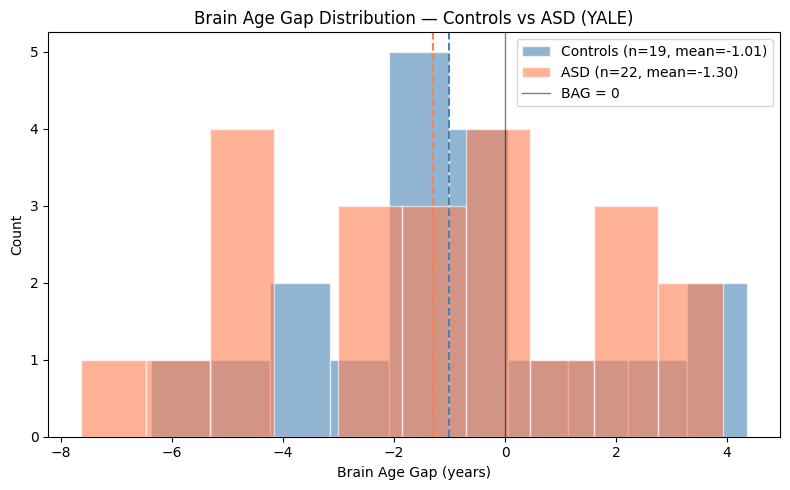

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(ctrl_bag, bins=10, alpha=0.6, color='steelblue', edgecolor='white', label=f'Controls (n=19, mean={ctrl_bag.mean():.2f})')
ax.hist(asd_bag, bins=10, alpha=0.6, color='coral', edgecolor='white', label=f'ASD (n=22, mean={asd_bag.mean():.2f})')

ax.axvline(ctrl_bag.mean(), color='steelblue', linestyle='--', linewidth=1.5)
ax.axvline(asd_bag.mean(), color='coral', linestyle='--', linewidth=1.5)
ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5, label='BAG = 0')

ax.set_xlabel('Brain Age Gap (years)')
ax.set_ylabel('Count')
ax.set_title('Brain Age Gap Distribution — Controls vs ASD (YALE)')
ax.legend()

plt.tight_layout()
plt.show()

## Statistical comparison

In [14]:
# Statistical Comparison

from scipy import stats

# Test for normality
_, p_ctrl = stats.shapiro(ctrl_bag)
_, p_asd = stats.shapiro(asd_bag)

print(f'Shapiro-Wilk normality test:')
print(f'Control BAG p-value: {p_ctrl:.3f}')
print(f'ASD BAG p-value: {p_asd:.3f}')

Shapiro-Wilk normality test:
Control BAG p-value: 0.897
ASD BAG p-value: 0.556


In [15]:
# Independent t-test between control and ASD BAG
stat, p_value = stats.ttest_ind(ctrl_bag, asd_bag)

print(f'Independent t-test:')
print(f'Statistic: {stat:.4f}')
print(f'P-value: {p_value:.4f}')
print(f'\nConclusion: {"Significant difference" if p_value < 0.05 else "No significant difference"} between control and ASD BAG (p={p_value:.4f})')

Independent t-test:
Statistic: 0.3053
P-value: 0.7617

Conclusion: No significant difference between control and ASD BAG (p=0.7617)
